In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [107]:
#load data
df = pd.read_csv('Weekly_Data.csv')

#prepare
for column in df[['propActive','propLying', 'propSitting', 'propStanding', 'propGrooming',
       'propLittering', 'propEating', 'propScratching']]:
    df[column] = [round(i,3)*100 for i in df[column]]

df["propOther"] = df[['propActive', 'propGrooming',
       'propLittering', 'propEating', 'propScratching']].sum(axis=1)

df.head()

,Cat_id,Season,Active,Lying,Sitting,Standing,Grooming,Littering,Eating,Scratching,...,Area,Diet,Coat,Owner,Owner_Age,Children,Cat1,Cat2,Dog,propOther
0,Cat1,Summer,27003,108903,281009,91712,66480,212,27813,1669,...,Rural,Mix,Short,Owner2,25 - 34 years,No,One,Single,Yes,20.4
1,Cat10,Summer,32589,219073,214569,48389,51391,403,36748,1639,...,Rural,Dry,Short,Owner8,55 - 65 years,No,One,Single,Yes,20.4
2,Cat11,Summer,33581,130668,346207,51024,34098,462,8331,430,...,Urban,Mix,Short,Owner15,45 - 54 years,No,Two,Multi,No,12.8
3,Cat12,Summer,25203,194934,286012,51434,29373,206,16823,816,...,Urban,Mix,Short,Owner12,25 - 34 years,No,Two,Multi,No,12.0
4,Cat13,Summer,14478,274497,144420,105333,17512,29,48344,188,...,Rural,Dry,Long,Owner16,25 - 34 years,No,One,Single,Yes,13.3


In [108]:
df.columns

Index(['Cat_id', 'Season', 'Active', 'Lying', 'Sitting', 'Standing',
       'Grooming', 'Littering', 'Eating', 'Scratching', 'Total', 'propActive',
       'propLying', 'propSitting', 'propStanding', 'propGrooming',
       'propLittering', 'propEating', 'propScratching', 'Cat_Age', 'Cat_Sex',
       'BW', 'BCS', 'BCS_ord', 'Housing', 'Area', 'Diet', 'Coat', 'Owner',
       'Owner_Age', 'Children', 'Cat1', 'Cat2', 'Dog', 'propOther'],
      dtype='object')

In [109]:
df[['propActive',
'propLying', 'propSitting', 'propStanding', 'propGrooming',
'propEating', 'propOther']].max()

propActive       8.2
propLying       61.9
propSitting     77.8
propStanding    31.8
propGrooming    12.6
propEating      13.6
propOther       25.1
dtype: float64

In [169]:
id = "Cat2"
season = "Summer"
data = df[(df["Cat_id"]==id) & (df["Season"]==season)]
values = data[['propOther', 'propStanding','propLying', 'propSitting']].values 
yvalues = sum([[x, 0] for x in values[0]], [])
yvalues = yvalues + [values[0][0]]
yvalues

[8.3, 0, 9.0, 0, 19.7, 0, 63.0, 0, 8.3]

In [153]:
theta = list(np.linspace(0, x_max, 8, endpoint=False))
theta = [theta[-1]] + theta + [theta[0]]
theta

[5.497787143782138,
 0.0,
 0.7853981633974483,
 1.5707963267948966,
 2.356194490192345,
 3.141592653589793,
 3.9269908169872414,
 4.71238898038469,
 5.497787143782138,
 0.0]

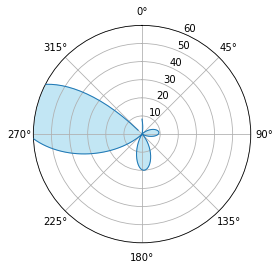

In [ ]:
#Build radar plot for single cat
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# calculate angular position
x_max = 2*np.pi
theta = np.linspace(0, x_max, 8, endpoint=False)
theta_smooth = np.linspace(0, x_max, 300, endpoint=False)

# Create smooth B-spline interpolator (degree 3 = cubic)
yvalues = sum([[x, 0] for x in values[0]], [])
spline = make_interp_spline(theta, yvalues, k=3)
y_smooth = spline(theta_smooth)

# plot data -----------------------------------------
ax.plot(list(theta_smooth), y_smooth, alpha=1, linewidth=1, zorder=3)
ax.fill_between(list(theta_smooth),0,  y_smooth,  color='skyblue', alpha=0.5)

# format axis -----------------------------------------
# set max value and offset from center
max_value = 60
r_offset = 0      
ax.set_rlim(0, max_value)
ax.set_rorigin(r_offset)

# start on the top and plot bars clockwise
ax.set_theta_zero_location('N')     
ax.set_theta_direction(-1)      

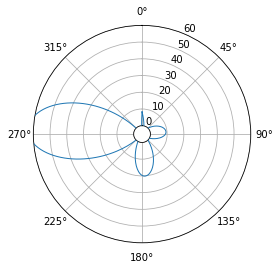

In [ ]:
#Build radar plot for single cat
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# calculate corect angular position in circular bar plot
x_max = 2*np.pi
theta = list(np.linspace(0, x_max, 9, endpoint=True))
theta_smooth = np.linspace(0, x_max, 300, endpoint=True)

# Create smooth B-spline interpolator (degree 3 = cubic)
spline = make_interp_spline(theta, yvalues, k=3)
y_smooth = spline(theta_smooth)

# plot data -----------------------------------------
values = [8,0,4,0,7,0,2,0]
ax.plot(list(theta_smooth), y_smooth, alpha=1, linewidth=1, zorder=3)

# format axis -----------------------------------------
# set max value and offset from center
max_value = 60
r_offset = -5      
ax.set_rlim(0, max_value)
ax.set_rorigin(r_offset)

# start on the top and plot bars clockwise
ax.set_theta_zero_location('N')     
ax.set_theta_direction(-1)      


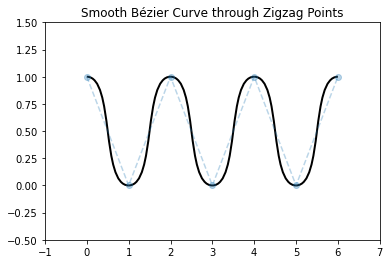

In [200]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches
import numpy as np

# Input points
y_values = [1, 0, 1, 0, 1, 0, 1]
x_values = list(range(len(y_values)))
points = list(zip(x_values, y_values))

# Create cubic Bézier segments
verts = []
codes = []

for i in range(len(points) - 1):
    p0 = points[i]
    p3 = points[i + 1]
    
    # Midpoints between p0 and p3
    dx = (p3[0] - p0[0]) / 3
    dy = (p3[1] - p0[1]) / 3
    
    # Control points to smooth curve
    cp1 = (p0[0] + 2* dx, p0[1])
    cp2 = (p0[0] + 1 * dx, p3[1])
    
    if i == 0:
        verts.append(p0)
        codes.append(Path.MOVETO)
    
    verts += [cp1, cp2, p3]
    codes += [Path.CURVE4, Path.CURVE4, Path.CURVE4]

# Create Path and Patch
path = Path(verts, codes)
patch = patches.PathPatch(path, facecolor='none', lw=2)

# Plot
fig, ax = plt.subplots()
ax.add_patch(patch)
ax.plot(x_values, y_values, 'o--', alpha=0.3)  # original points for reference
ax.set_xlim(-1, len(y_values))
ax.set_ylim(-0.5, 1.5)
plt.title("Smooth Bézier Curve through Zigzag Points")
plt.show()

In [206]:


# Retrieve path data
path_data = patch.get_path().vertices  # This gives you the (x, y) coordinates
path_data

array([[0.        , 1.        ],
       [0.66666667, 1.        ],
       [0.33333333, 0.        ],
       [1.        , 0.        ],
       [1.66666667, 0.        ],
       [1.33333333, 1.        ],
       [2.        , 1.        ],
       [2.66666667, 1.        ],
       [2.33333333, 0.        ],
       [3.        , 0.        ],
       [3.66666667, 0.        ],
       [3.33333333, 1.        ],
       [4.        , 1.        ],
       [4.66666667, 1.        ],
       [4.33333333, 0.        ],
       [5.        , 0.        ],
       [5.66666667, 0.        ],
       [5.33333333, 1.        ],
       [6.        , 1.        ]])

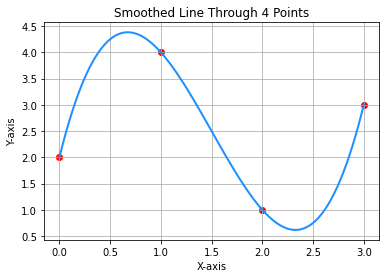

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Original 4 points
x = np.array([0, 1, 2, 3])
y = np.array([2, 4, 1, 3])

# Create smooth x values
x_smooth = np.linspace(x.min(), x.max(), 300)

# Create B-spline interpolator (degree 3 = cubic)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Plot
plt.plot(x_smooth, y_smooth, color='dodgerblue', linewidth=2)
plt.scatter(x, y, color='red')  # Optional: show original points
plt.title("Smoothed Line Through 4 Points")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()

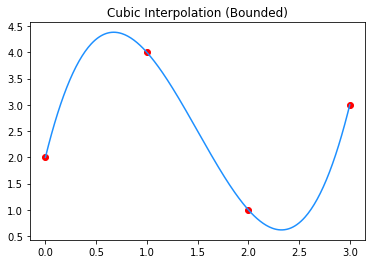

In [94]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3])
y = np.array([2, 4, 1, 3])

f = interp1d(x, y, kind='cubic')
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = f(x_smooth)

plt.plot(x_smooth, y_smooth, color='dodgerblue')
plt.scatter(x, y, color='red')
plt.title("Cubic Interpolation (Bounded)")
plt.show()

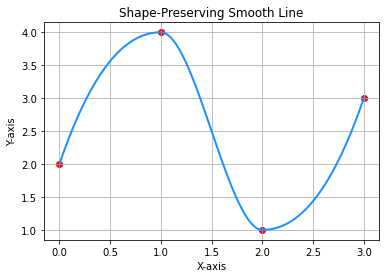

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Original data
x = np.array([0, 1, 2, 3])
y = np.array([2, 4, 1, 3])

# Create shape-preserving interpolator
pchip = PchipInterpolator(x, y)

# Smooth x values
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = pchip(x_smooth)

# Plot
plt.plot(x_smooth, y_smooth, color='dodgerblue', linewidth=2)
plt.scatter(x, y, color='red')
plt.title("Shape-Preserving Smooth Line")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()